## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_bar=10,
# plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="dpca",
    scaling_mode="global_mean",
    data_dir="data_csv",            # Ordner mit den vier TEP-CSVs

    # Lags L -> 52*(L+1) = 156 Spalten im gestapelten Signal.
    dpca_lags=2,

    # Linienplots zeigen die ersten k_max Komponenten von 156.
    k_max=25,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne DPCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500


,faultNumber,simulationRun,dpca_1,dpca_2,dpca_3,dpca_4,dpca_5,dpca_6,dpca_7,dpca_8,...,dpca_147,dpca_148,dpca_149,dpca_150,dpca_151,dpca_152,dpca_153,dpca_154,dpca_155,dpca_156
0,0,1,0.327481,0.200619,0.142276,0.112729,0.089133,0.066599,0.029972,0.016955,...,4.570292e-10,3.003740e-10,9.755979e-11,8.877982e-11,8.269905e-12,7.639573e-12,7.097903e-12,6.901976e-12,6.545777e-12,6.419501e-12
1,0,2,0.323807,0.195098,0.123324,0.100350,0.076078,0.067183,0.052117,0.049420,...,3.898484e-10,3.019052e-10,7.777803e-11,7.349748e-11,7.158435e-12,6.608005e-12,6.339651e-12,5.948886e-12,5.527731e-12,4.546368e-12
2,0,3,0.280967,0.200192,0.127537,0.113397,0.090986,0.082202,0.063741,0.026586,...,4.670380e-10,3.593330e-10,7.835034e-11,6.896915e-11,7.401476e-12,7.260063e-12,6.813333e-12,6.187600e-12,5.607756e-12,5.092177e-12
3,0,4,0.288930,0.204825,0.139441,0.126061,0.097578,0.060477,0.040671,0.028067,...,4.017481e-10,2.885157e-10,9.546313e-11,8.155269e-11,7.903414e-12,7.188341e-12,6.299820e-12,5.916321e-12,5.542634e-12,5.188528e-12
4,0,5,0.379033,0.171654,0.135233,0.102819,0.078422,0.060877,0.038730,0.020040,...,3.566210e-10,2.095235e-10,8.657373e-11,7.647753e-11,7.520977e-12,7.302475e-12,6.835001e-12,6.719224e-12,6.226816e-12,5.390674e-12


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte DPCA-Statistiken pro Fault: (21, 313)


d:\CCS\Forschung\tep\eigen\aggregate.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg = agg.reset_index()


,faultNumber,dpca_1_mean,dpca_1_std,dpca_2_mean,dpca_2_std,dpca_3_mean,dpca_3_std,dpca_4_mean,dpca_4_std,dpca_5_mean,...,dpca_152_mean,dpca_152_std,dpca_153_mean,dpca_153_std,dpca_154_mean,dpca_154_std,dpca_155_mean,dpca_155_std,dpca_156_mean,dpca_156_std
0,0,0.314797,0.034851,0.200869,0.020442,0.138187,0.012884,0.114520,0.010511,0.084409,...,7.272059e-12,7.389026e-13,6.750828e-12,6.902316e-13,6.256390e-12,6.447699e-13,5.788007e-12,6.053470e-13,5.184784e-12,6.026134e-13
1,1,0.590026,0.042988,0.154242,0.011548,0.107171,0.015566,0.046605,0.008386,0.030975,...,1.568494e-12,2.609937e-13,1.448100e-12,2.371385e-13,1.343707e-12,2.220369e-13,1.238647e-12,2.062761e-13,1.094568e-12,1.864500e-13
2,2,0.532276,0.021580,0.216015,0.019562,0.074390,0.008625,0.051284,0.004407,0.042450,...,2.648957e-12,2.133025e-13,2.449860e-12,1.929182e-13,2.268766e-12,1.781139e-13,2.088098e-12,1.737542e-13,1.863704e-12,1.840324e-13
3,3,0.317070,0.035697,0.199913,0.020767,0.137489,0.012927,0.113708,0.010713,0.083875,...,7.077548e-12,7.807501e-13,6.556238e-12,7.114104e-13,6.097276e-12,6.667627e-13,5.625744e-12,6.384387e-13,5.017945e-12,6.200995e-13
4,4,0.317076,0.035612,0.199906,0.020740,0.137495,0.012922,0.113703,0.010693,0.083880,...,7.080580e-12,7.579008e-13,6.527626e-12,6.818099e-13,6.058986e-12,6.208680e-13,5.597594e-12,5.889216e-13,4.986452e-12,5.779720e-13


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

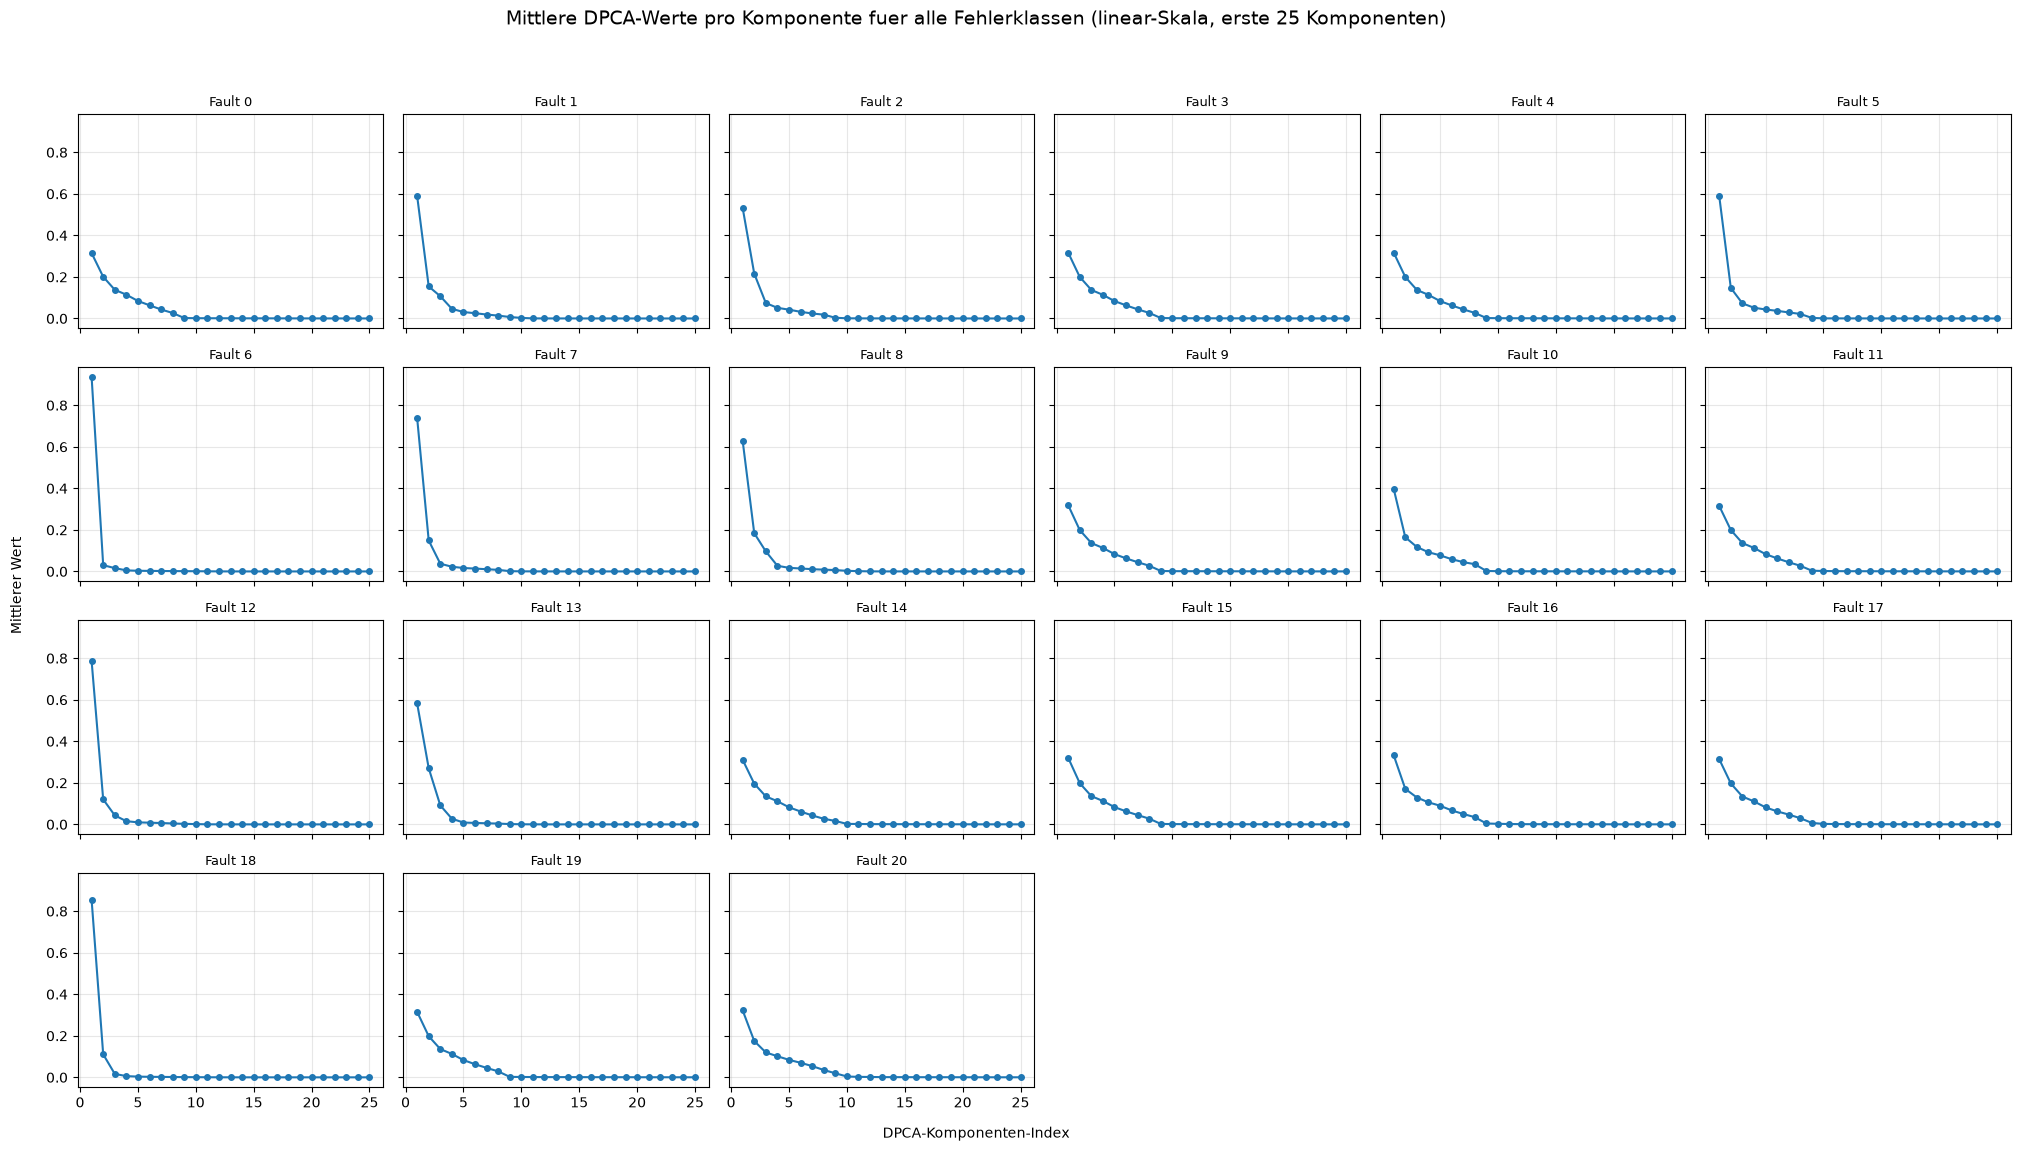

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

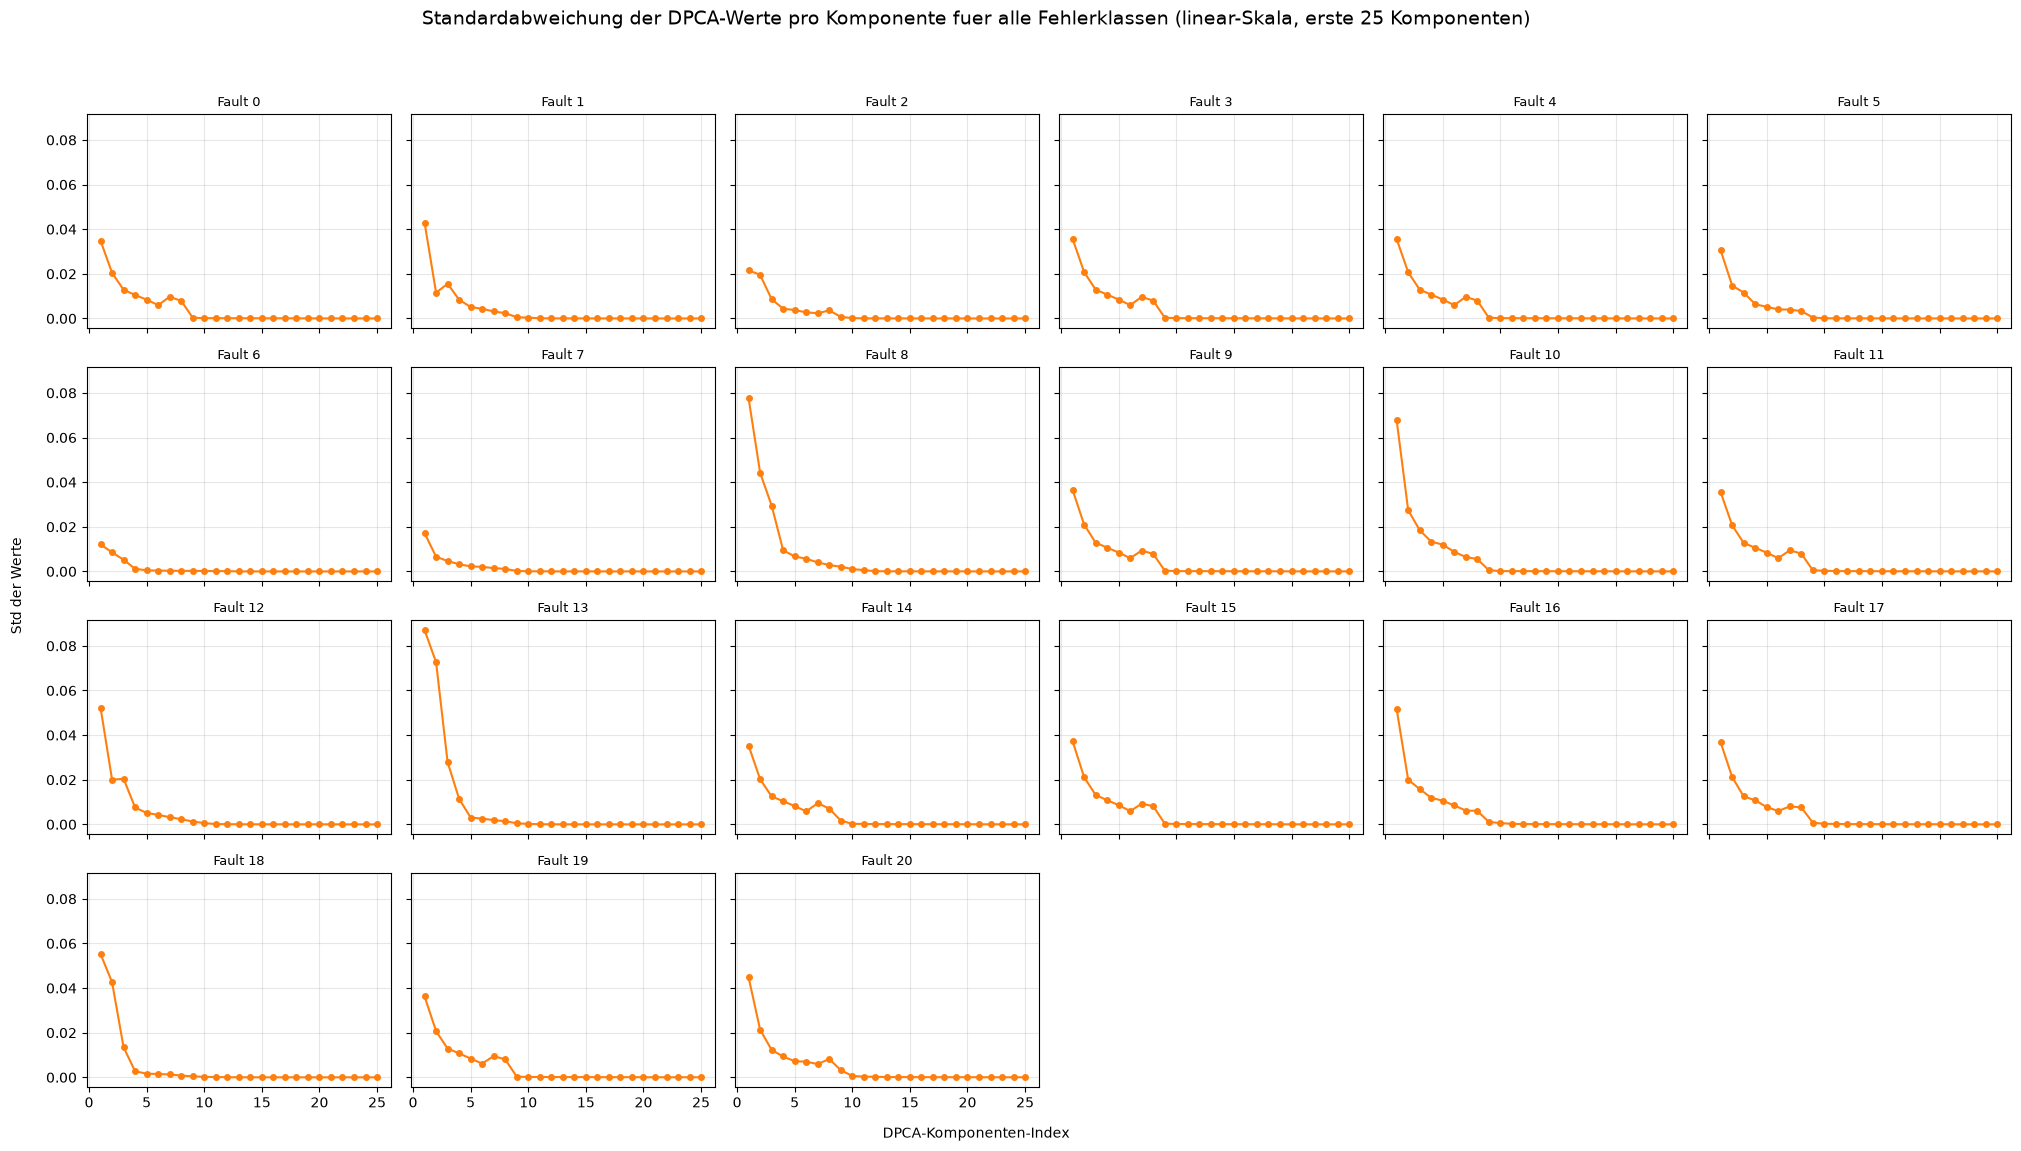

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

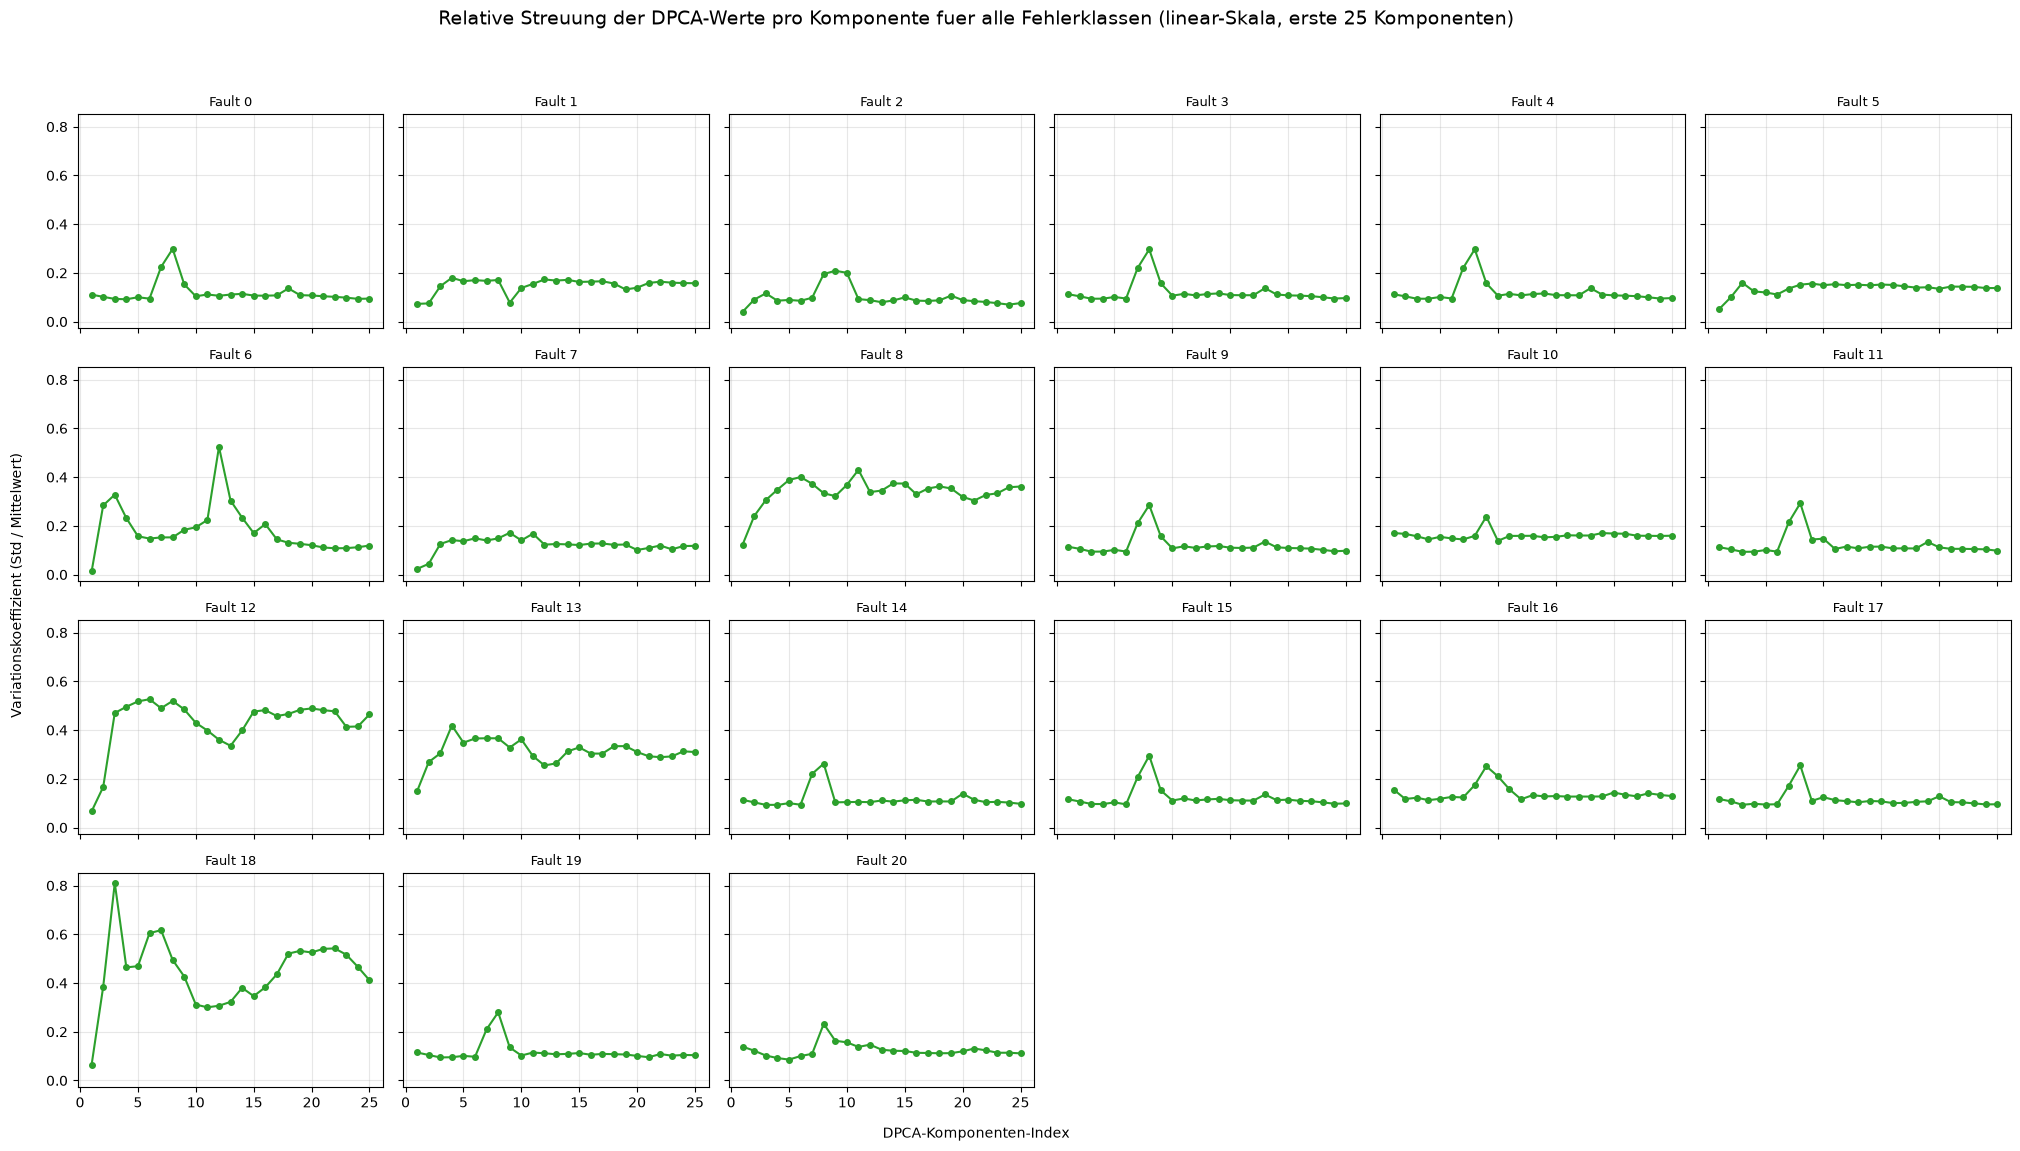

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

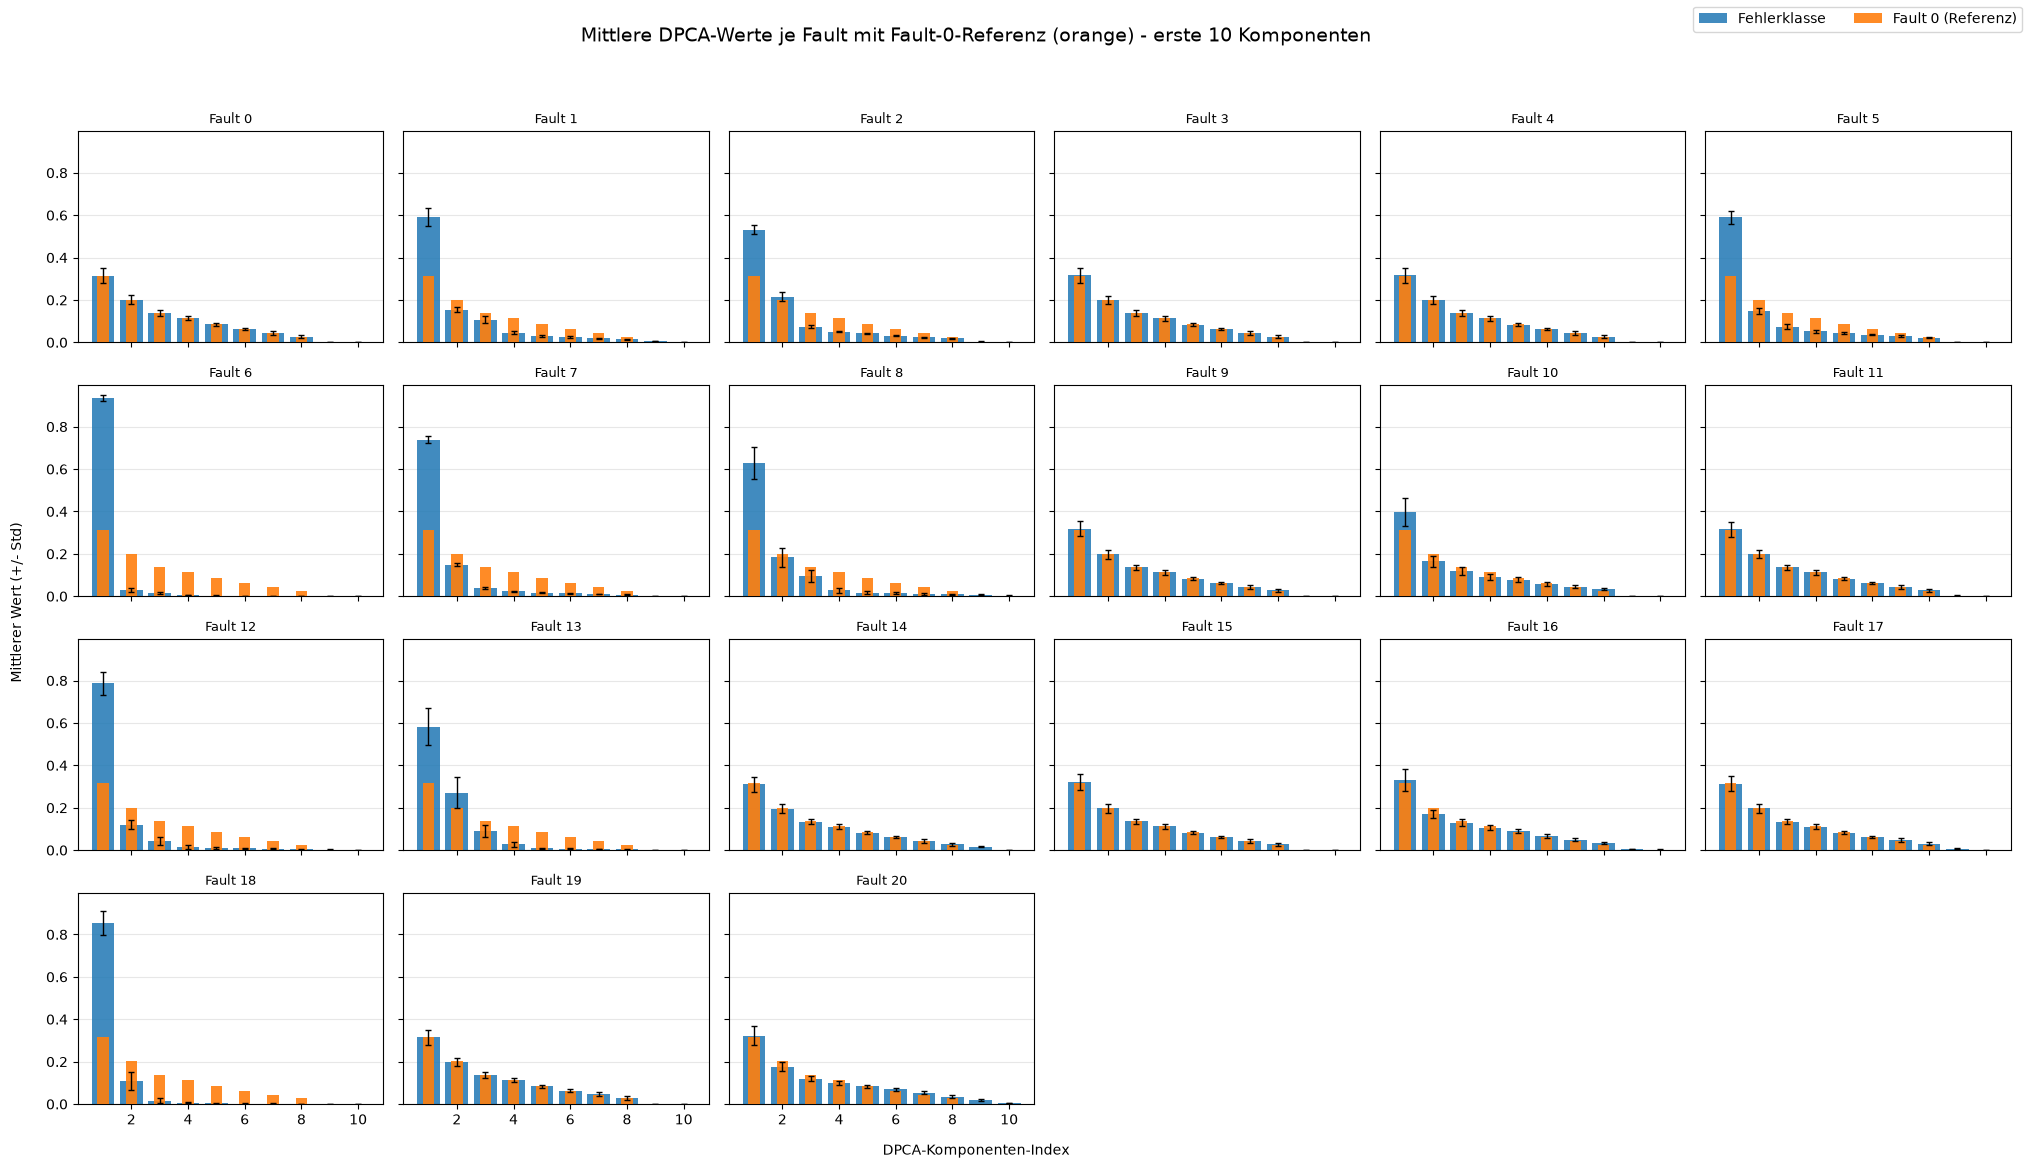

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `dpca_eigenvalues_train.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

DPCA-Train gespeichert: (10500, 158) -> .\dpca_eigenvalues_train.csv


'.\\dpca_eigenvalues_train.csv'